# 📊 InsightML Studio
# Notebook 02 — Exploratory Data Analysis (EDA)

## 🎯 Objective

This notebook performs an in-depth exploratory data analysis (EDA) on the banking customer churn dataset.

The objectives are:

- Understand feature distributions
- Analyze target variable (Churn)
- Detect missing values
- Identify outliers
- Study feature correlations
- Discover customer behavior patterns
- Generate business insights
- Prepare for preprocessing and feature engineering

This notebook is dataset-aware and automatically adapts to numerical and categorical variables.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import missingno as msno

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

DATA_PATH = "../data/raw/bank_customer_churn.csv"

df = pd.read_csv(DATA_PATH)

print("✅ Dataset Loaded Successfully")

display(df.head())

✅ Dataset Loaded Successfully


,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [3]:
# ==========================================================
# Dataset Overview
# ==========================================================

rows, cols = df.shape

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Rows               : {rows:,}")
print(f"Columns            : {cols}")
print(f"Duplicate Rows     : {df.duplicated().sum()}")
print(f"Memory Usage       : {round(df.memory_usage(deep=True).sum()/1024**2,2)} MB")

print("\n")

display(df.describe(include="all").T)

DATASET OVERVIEW
Rows               : 28,382
Columns            : 21
Duplicate Rows     : 0
Memory Usage       : 8.54 MB




,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,28382.0,NaN,NaN,NaN,15143.508667,8746.454456,1.0,7557.25,15150.5,22706.75,30301.0
vintage,28382.0,NaN,NaN,NaN,2091.144105,272.676775,73.0,1958.0,2154.0,2292.0,2476.0
age,28382.0,NaN,NaN,NaN,48.208336,17.807163,1.0,36.0,46.0,60.0,90.0
gender,27857,2,Male,16548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,25919.0,NaN,NaN,NaN,0.347236,0.997661,0.0,0.0,0.0,0.0,52.0
occupation,28302,5,self_employed,17476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,27579.0,NaN,NaN,NaN,796.109576,432.872102,0.0,409.0,834.0,1096.0,1649.0
customer_nw_category,28382.0,NaN,NaN,NaN,2.22553,0.660443,1.0,2.0,2.0,3.0,3.0
branch_code,28382.0,NaN,NaN,NaN,925.975019,937.799129,1.0,176.0,572.0,1440.0,4782.0
current_balance,28382.0,NaN,NaN,NaN,7380.551804,42598.711923,-5503.96,1784.47,3281.255,6635.82,5905904.03


In [4]:
# ==========================================================
# Target Column
# ==========================================================

target = "churn"

print(f"Target Column : {target}")

Target Column : churn


churn
0    23122
1     5260
Name: count, dtype: int64


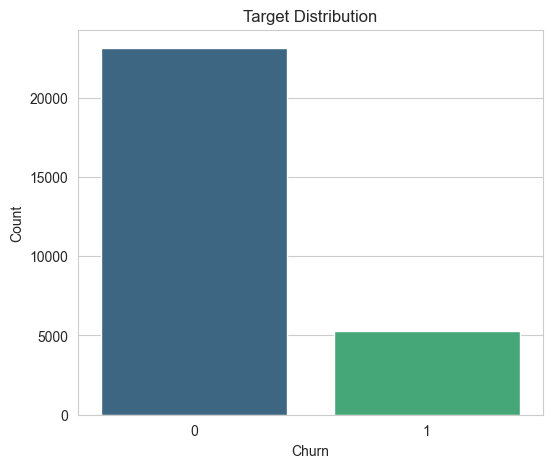

In [5]:
# ==========================================================
# Target Distribution
# ==========================================================

print(df[target].value_counts())

plt.figure(figsize=(6,5))

sns.countplot(
    x=df[target],
    palette="viridis"
)

plt.title("Target Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

churn
0    81.47
1    18.53
Name: proportion, dtype: float64

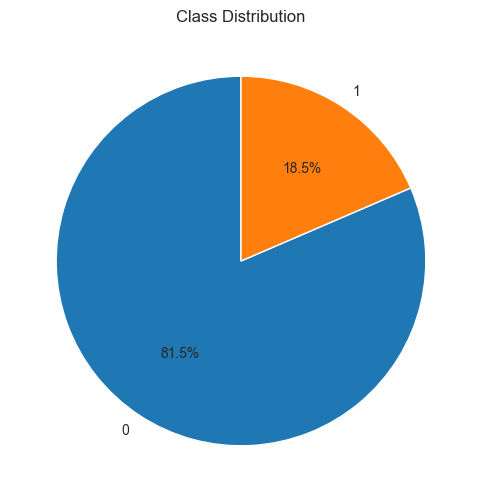

In [6]:
# ==========================================================
# Class Distribution (%)
# ==========================================================

class_percent = (
    df[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(class_percent)

plt.figure(figsize=(6,6))

plt.pie(
    class_percent,
    labels=class_percent.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Distribution")

plt.show()

In [7]:
# ==========================================================
# Numerical Columns
# ==========================================================

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f"Total Numerical Columns : {len(numerical_cols)}")

numerical_cols

Total Numerical Columns : 18


['customer_id',
 'vintage',
 'age',
 'dependents',
 'city',
 'customer_nw_category',
 'branch_code',
 'current_balance',
 'previous_month_end_balance',
 'average_monthly_balance_prevQ',
 'average_monthly_balance_prevQ2',
 'current_month_credit',
 'previous_month_credit',
 'current_month_debit',
 'previous_month_debit',
 'current_month_balance',
 'previous_month_balance',
 'churn']

In [8]:
# ==========================================================
# Categorical Columns
# ==========================================================

categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Total Categorical Columns : {len(categorical_cols)}")

categorical_cols

Total Categorical Columns : 3


['gender', 'occupation', 'last_transaction']

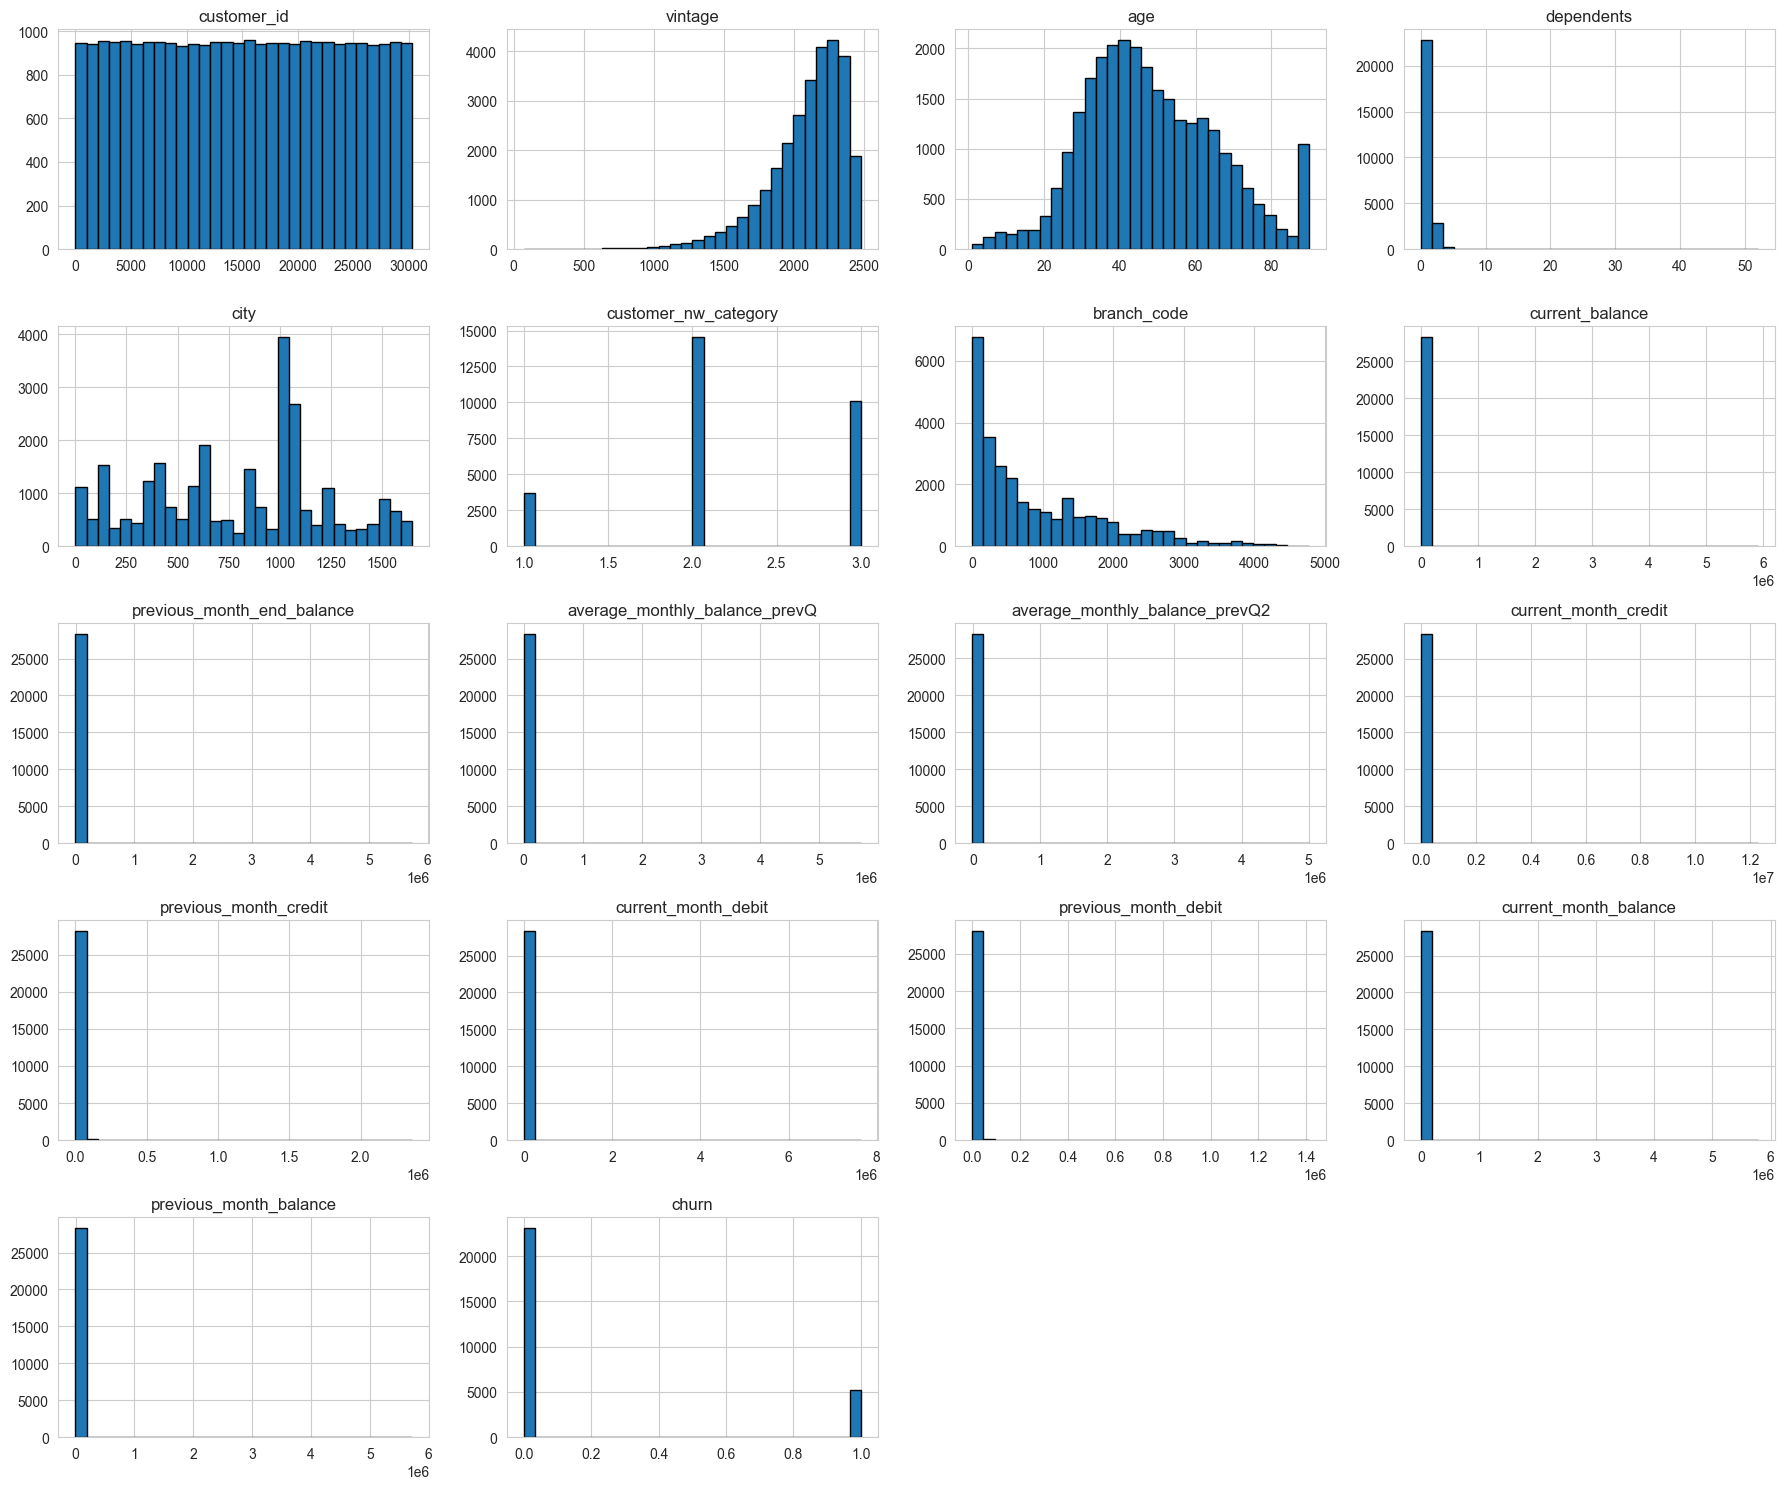

In [9]:
# ==========================================================
# Histograms
# ==========================================================

df[numerical_cols].hist(

    figsize=(18,15),

    bins=30,

    edgecolor="black"

)

plt.tight_layout()

plt.show()

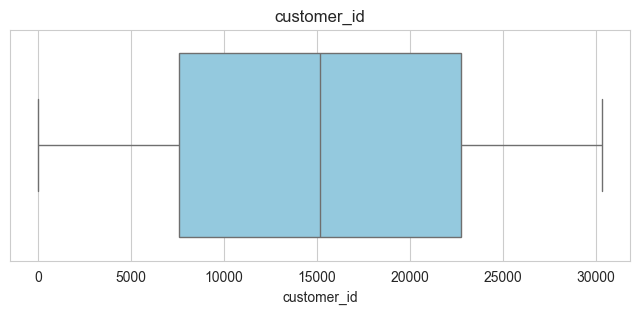

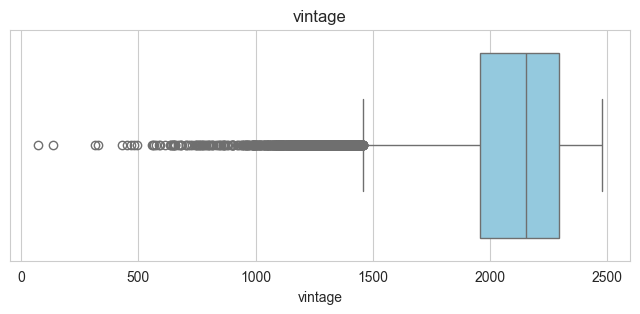

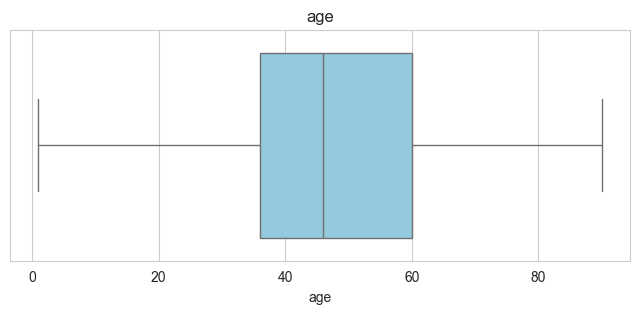

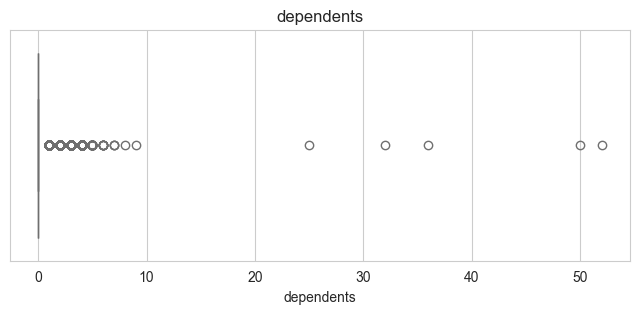

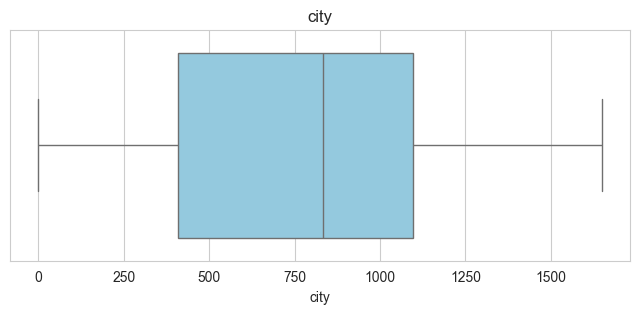

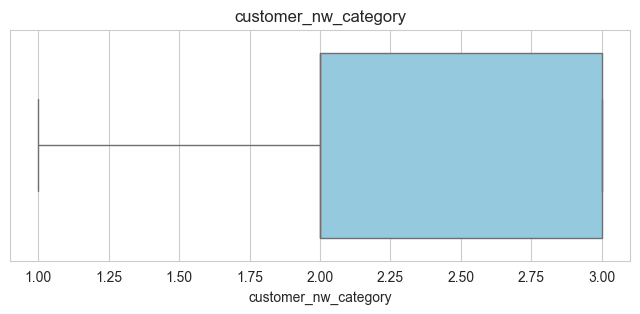

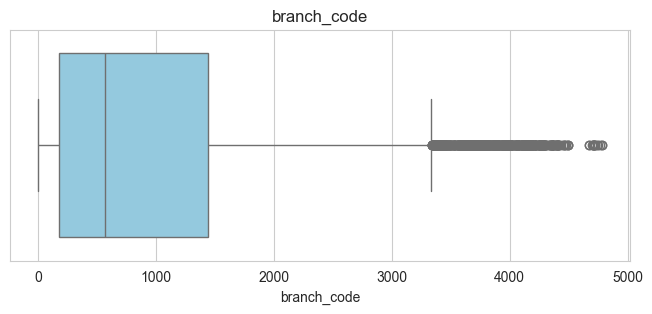

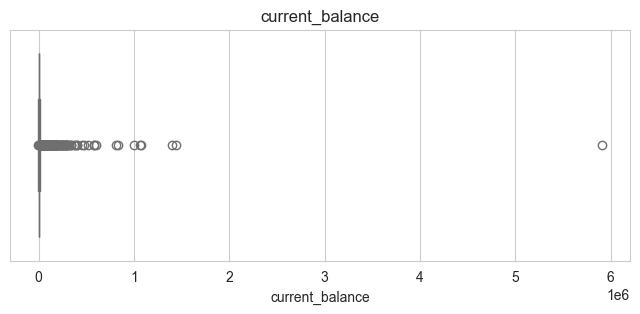

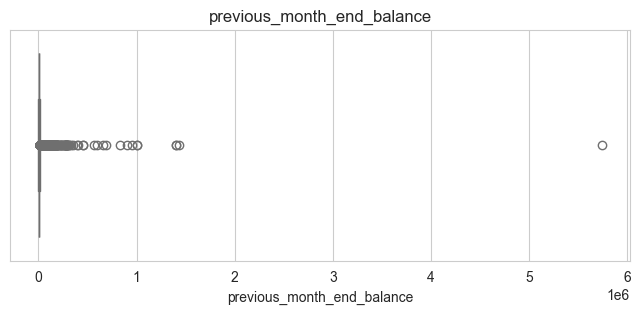

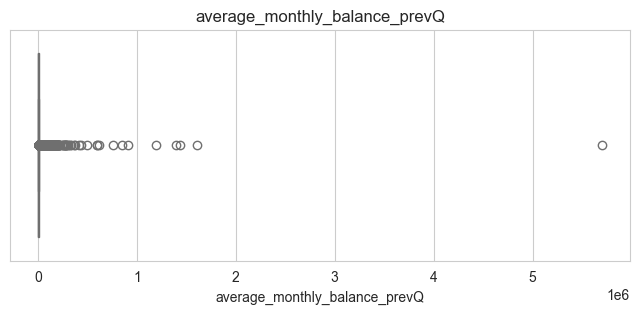

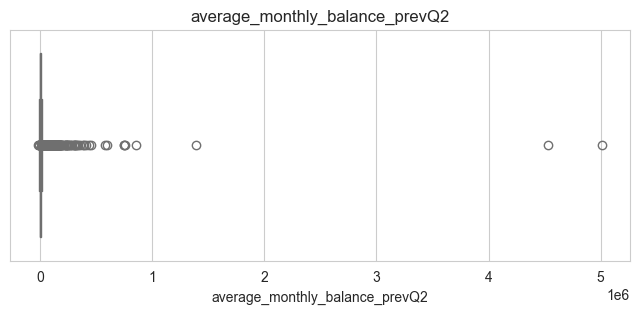

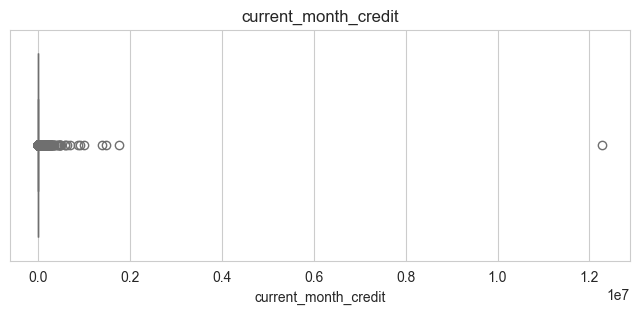

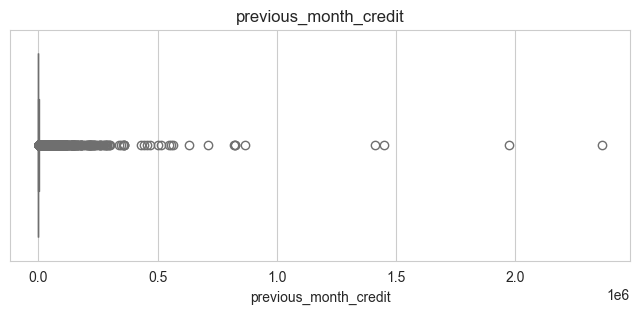

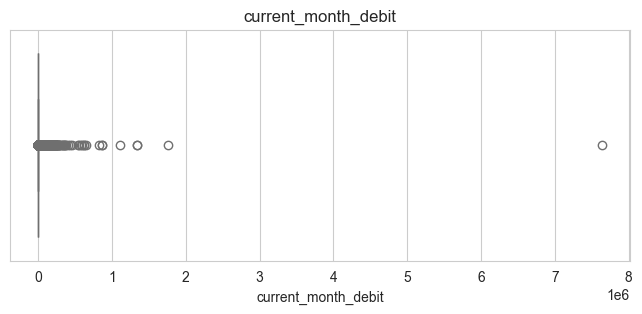

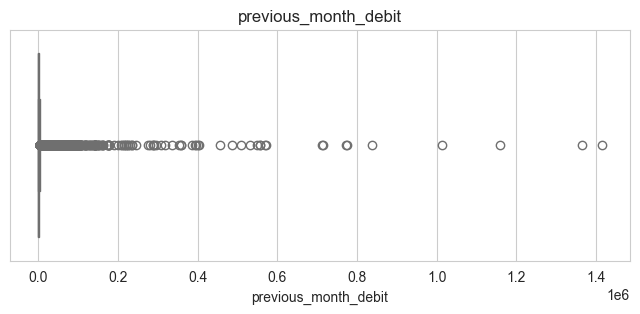

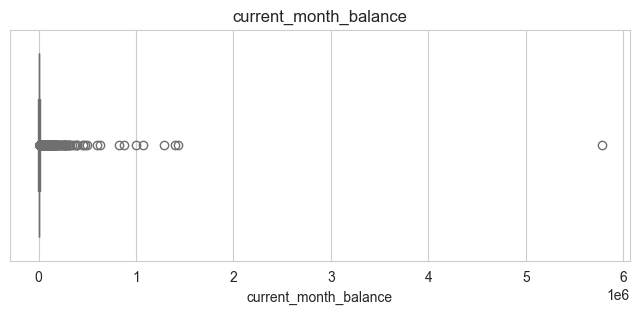

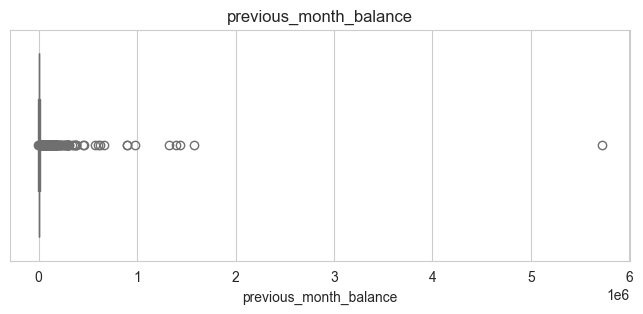

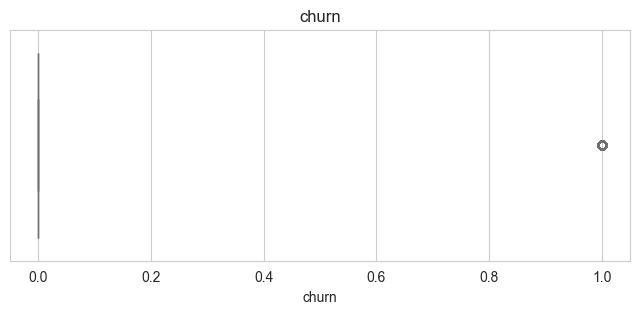

In [10]:
# ==========================================================
# Boxplots
# ==========================================================

for col in numerical_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df[col],
        color="skyblue"
    )

    plt.title(col)

    plt.show()

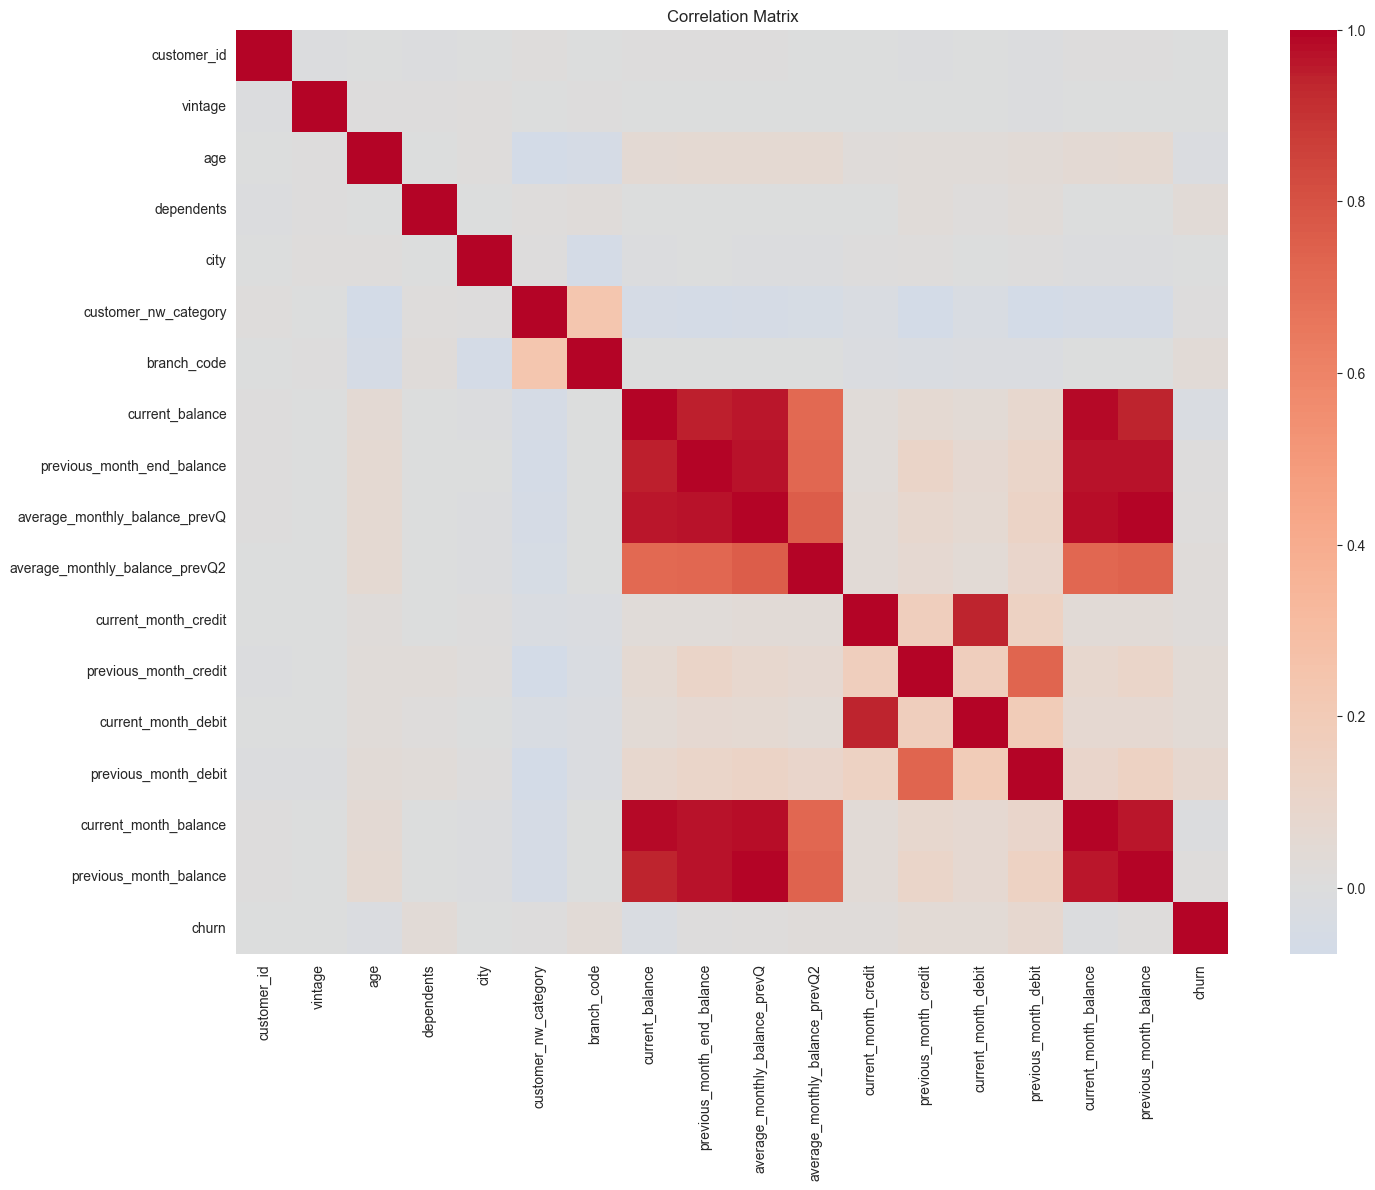

In [11]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(16,12))

corr = df[numerical_cols].corr()

sns.heatmap(

    corr,

    cmap="coolwarm",

    center=0

)

plt.title("Correlation Matrix")

plt.show()

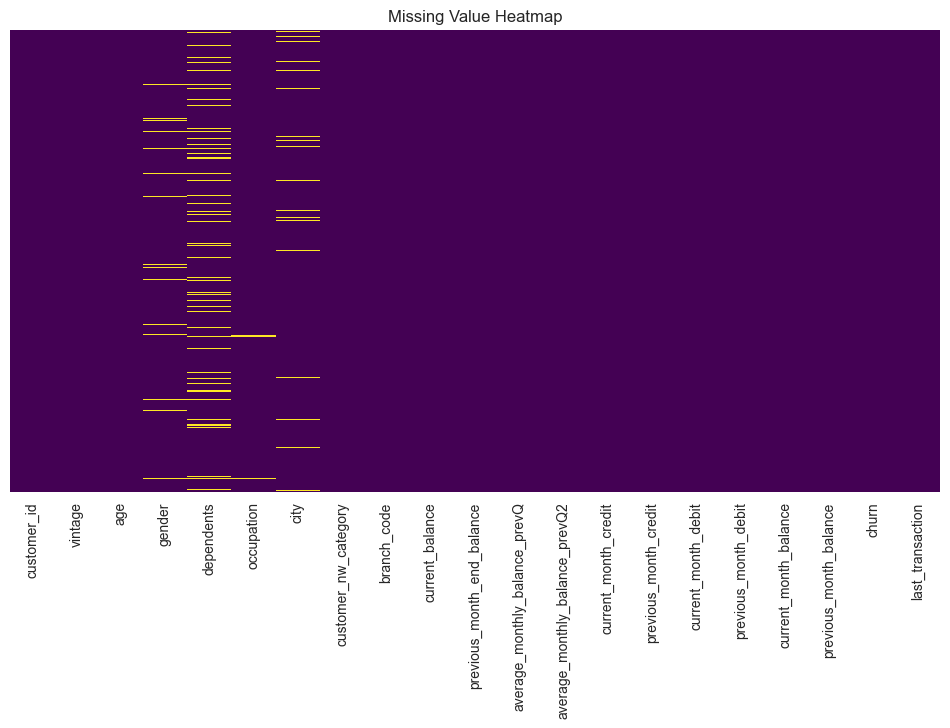

In [12]:
# ==========================================================
# Missing Value Heatmap
# ==========================================================

plt.figure(figsize=(12,6))

sns.heatmap(

    df.isnull(),

    cbar=False,

    yticklabels=False,

    cmap="viridis"

)

plt.title("Missing Value Heatmap")

plt.show()

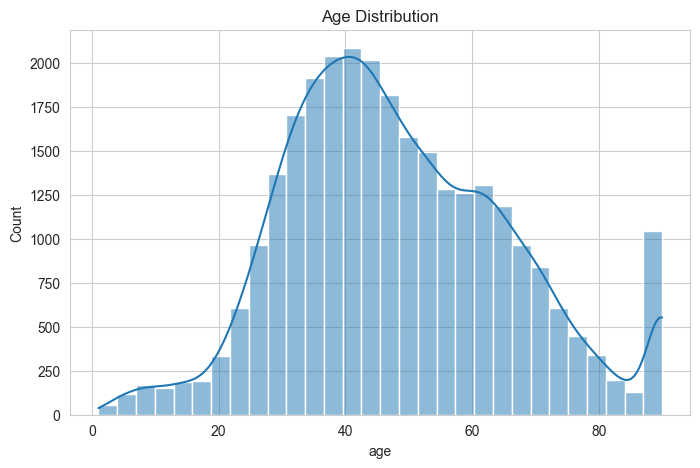

In [13]:
# ==========================================================
# Age Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(

    data=df,

    x="age",

    bins=30,

    kde=True

)

plt.title("Age Distribution")

plt.show()

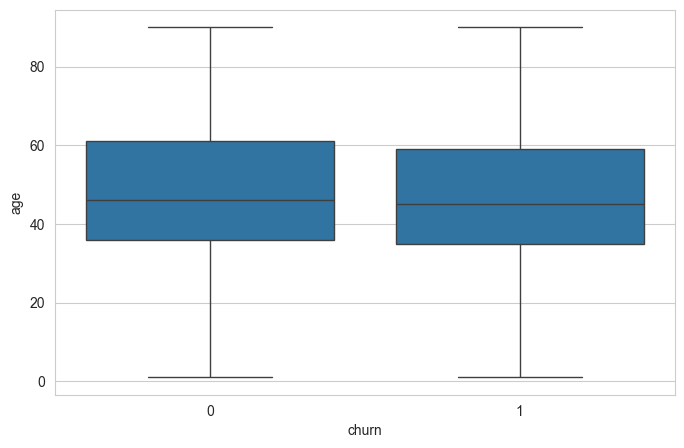

In [14]:
# ==========================================================
# Age vs Churn
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(

    data=df,

    x="churn",

    y="age"

)

plt.show()

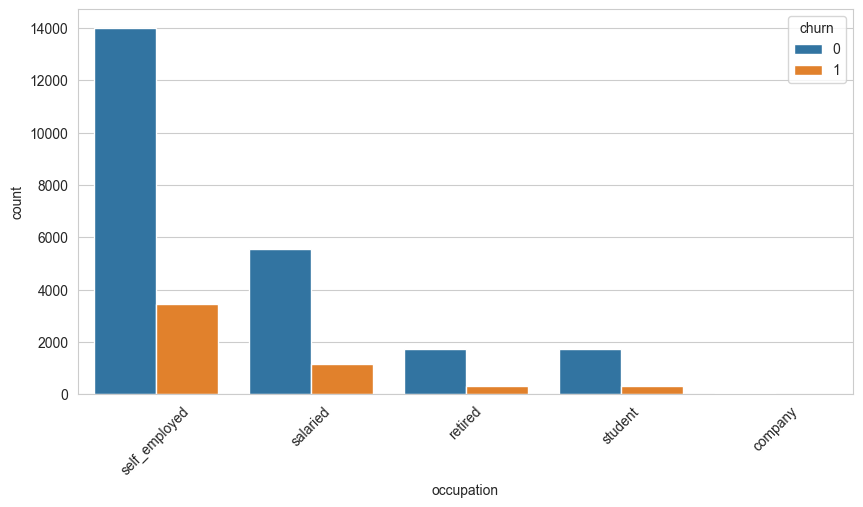

In [15]:
# ==========================================================
# Occupation vs Churn
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(

    data=df,

    x="occupation",

    hue="churn"

)

plt.xticks(rotation=45)

plt.show()

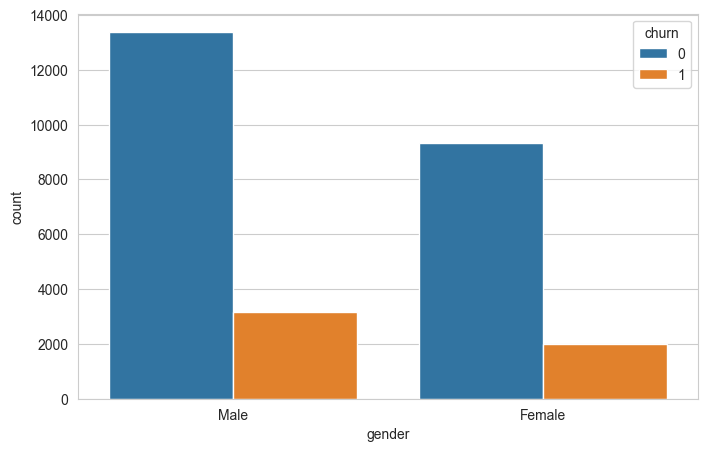

In [16]:
# ==========================================================
# Gender vs Churn
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(

    data=df,

    x="gender",

    hue="churn"

)

plt.show()

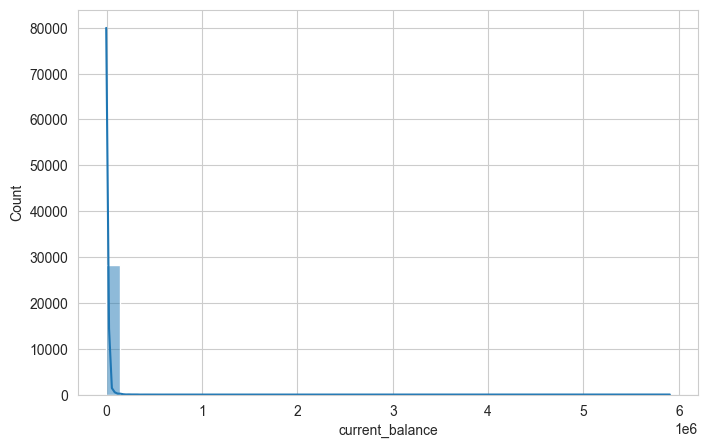

In [17]:
# ==========================================================
# Current Balance Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(

    df["current_balance"],

    bins=40,

    kde=True

)

plt.show()

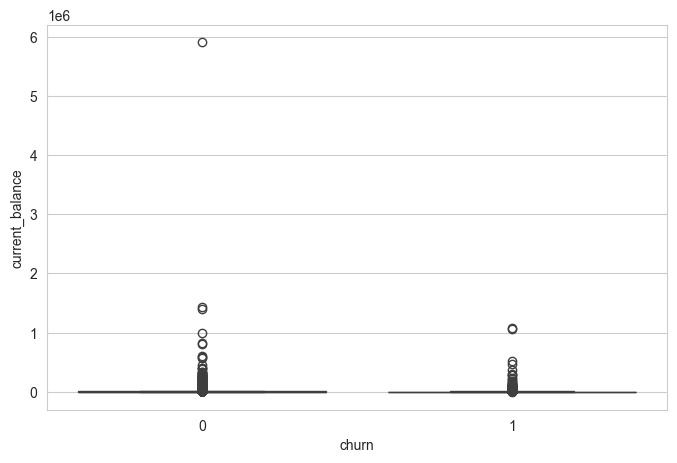

In [18]:
# ==========================================================
# Current Balance vs Churn
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(

    data=df,

    x="churn",

    y="current_balance"

)

plt.show()

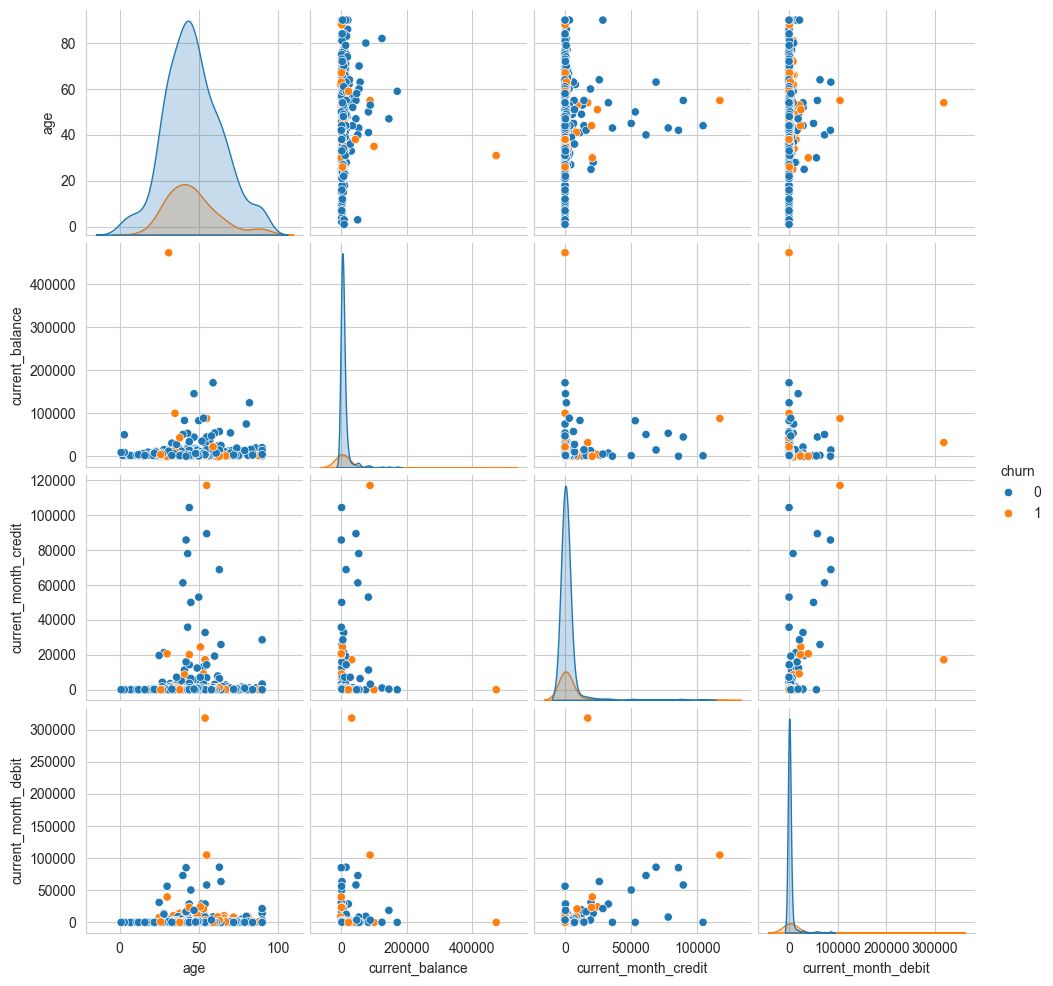

In [19]:
# ==========================================================
# Pairplot
# ==========================================================

sample = df.sample(500, random_state=42)

sns.pairplot(

    sample[["age","current_balance","current_month_credit","current_month_debit","churn"]],

    hue="churn"

)

plt.show()

In [20]:
# ==========================================================
# Skewness Analysis
# ==========================================================

skew = df[numerical_cols].skew()

display(skew.sort_values(ascending=False))

current_month_credit              143.315551
current_month_debit               115.620280
current_balance                    99.030683
current_month_balance              97.313457
average_monthly_balance_prevQ      96.648620
previous_month_balance             93.398645
previous_month_end_balance         92.948220
average_monthly_balance_prevQ2     88.893453
previous_month_credit              42.560005
previous_month_debit               30.641984
dependents                         15.185815
churn                               1.619748
branch_code                         1.245675
age                                 0.330589
customer_id                         0.000505
city                               -0.076553
customer_nw_category               -0.281379
vintage                            -1.388936
dtype: float64

# 📌 Business Insights

### Key Findings

- Dataset is imbalanced (~18.5% churn vs ~81.5% non-churn).
- Missing values exist in gender, dependents, city, and occupation.
- Several financial features are highly skewed.
- Customer balance varies significantly between churn groups.
- Age appears to influence churn behavior.
- Occupation and gender may contribute to churn prediction.
- Correlation analysis reveals relationships among balance and transaction features.
- Outliers are present and should be handled during preprocessing.
- Scaling and encoding will be necessary before model training.

### Next Step

Proceed to **Notebook 03 — Data Preprocessing** to clean, transform, and prepare the dataset for machine learning.
